In [1]:
import numpy as np
import matplotlib.pyplot as plt
cmap = 'tab10'
import pandas as pd

import copy
import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix


from sklearn.decomposition import PCA

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

# Load data

In [2]:
import torchvision
import torch
from torchvision import transforms

mnist = torchvision.datasets.MNIST(root = '../../clustering_embedding/mnist/', train = True, download = False,  transform=transforms.Compose([
                                                              transforms.ToTensor()]))

mnist_ims = torch.stack([data for data, _ in mnist])
labels =  np.array([data for _, data in mnist])

In [3]:
pca = PCA(n_components = 50)
mnist = pca.fit_transform(mnist_ims.reshape(60000,-1))

In [4]:
n = mnist.shape[0]

# Clusters

Vary the number of clusters obtained

In [5]:
%%time
adata = sc.AnnData(mnist)
sc.pp.neighbors(adata, n_neighbors=15)

CPU times: total: 46.5 s
Wall time: 46.6 s


In [6]:
%%time
sc.tl.leiden(adata, resolution=0.3) #set resolution so that have 10 clusters
clusters_10 = copy.deepcopy(adata.obs['leiden'])
clusters_10 = np.array(clusters_10).astype(int)
rand_score(clusters_10, labels)

<timed exec>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: total: 9.44 s
Wall time: 9.47 s


0.9895651888642588

In [9]:
%%time
sc.tl.leiden(adata, resolution=0.1) 
len(np.unique(adata.obs['leiden']))
clusters_7 = copy.deepcopy(adata.obs['leiden'])
clusters_7 = np.array(clusters_7).astype(int)
rand_score(clusters_7, labels)

CPU times: total: 10.3 s
Wall time: 10.3 s


0.9184314044122958

In [15]:
%%time
sc.tl.leiden(adata, resolution=1) 
clusters_16 = copy.deepcopy(adata.obs['leiden'])
clusters_16 = np.array(clusters_16).astype(int)
rand_score(clusters_16, labels)

CPU times: total: 16 s
Wall time: 16 s


0.9668295982710823

In [11]:
%%time
sc.tl.leiden(adata, resolution=0.8) 
clusters_12 = copy.deepcopy(adata.obs['leiden'])
clusters_12 = np.array(clusters_12).astype(int)
rand_score(clusters_12, labels)

CPU times: total: 16.7 s
Wall time: 16.8 s


0.9799386934226682

In [16]:
sc.tl.leiden(adata, resolution=1.5) 
clusters_24 = copy.deepcopy(adata.obs['leiden'])
clusters_24 = np.array(clusters_24).astype(int)
rand_score(clusters_24, labels)

0.9435461057684295

In [18]:
sc.tl.leiden(adata, resolution=0.025) 
clusters_4 = copy.deepcopy(adata.obs['leiden'])
clusters_4 = np.array(clusters_4).astype(int)
rand_score(clusters_4, labels)

0.7428385206420107

In [19]:
len(np.unique(clusters_10)), len(np.unique(clusters_7)), len(np.unique(clusters_12)), len(np.unique(clusters_16)), len(np.unique(clusters_4)), len(np.unique(clusters_24))

(10, 7, 12, 16, 4, 24)

## Embed and align

In [27]:
# %%time
# approximate geodesic distances 
alignment_idxs = np.random.choice(n, 20000, replace = False)
D = shortest_path(
    (adata[alignment_idxs]).obsp["distances"],
    directed=False,
    indices= np.arange(5000) # only compute from these sources
)


alignment_idxs = alignment_idxs[0:5000]
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]
D = D[:,0:5000]
D[np.isinf(D)] =  np.max(D[np.isfinite(D)]) # replace infinite values

In [29]:
clusters = clusters_4

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]

In [30]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_4 = out.align_embedding(m = 50 )
ce_4 =  out.embed_points(embeddings,clusters)

In [33]:
clusters = clusters_7

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]


In [36]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_7 = out.align_embedding(m = 50 )
ce_7 =  out.embed_points(embeddings,clusters)

In [71]:
clusters = clusters_12

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]


In [91]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_12 = out.align_embedding(m = 50 )
ce_12 =  out.embed_points(embeddings,clusters)

In [41]:
clusters = clusters_16

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):
    cluster_emb = l_isomap.fit_transform(adata[clusters == i])
    embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)

embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]


In [44]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_16 = out.align_embedding(m = 50 )
ce_16 =  out.embed_points(embeddings,clusters)

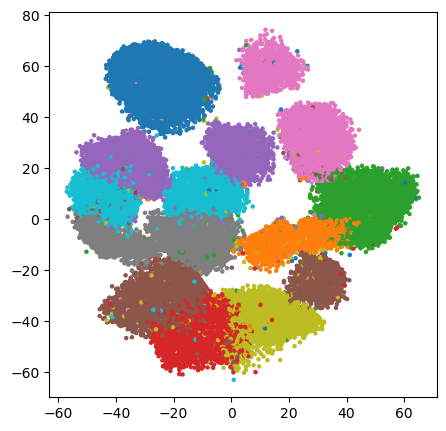

In [45]:
plt.figure(figsize = [5,5])
plt.scatter(ce_16[:,0], ce_16[:,1], c = labels, cmap = 'tab10', s = 5)

In [47]:
clusters = clusters_24

l_isomap  = LandmarkIsomap(n_components = 2, n_landmarks = 300)
embeddings = np.zeros((n,2))
for i in np.unique(clusters):

    cc = np.sum(clusters == i)
    if cc > 300:
        cluster_emb = l_isomap.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
    else:
        l_isomap_temp = LandmarkIsomap(n_components = 2, n_landmarks = cc)
        cluster_emb = l_isomap_temp.fit_transform(adata[clusters == i])
        embeddings[clusters == i] = cluster_emb - np.mean(cluster_emb, axis = 0)
        
embedding_sampled = embeddings[alignment_idxs]
clusters_sampled = clusters[alignment_idxs]

distances = {} 

n_clusters = len(np.unique(clusters))
for i in range(n_clusters):
     for j in range(i+1, n_clusters):
            distances[i,j] = D[clusters_sampled == i, :][:,clusters_sampled == j]

In [52]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.75)
ce_24 = out.align_embedding(m = 50 )
ce_24 =  out.embed_points(embeddings,clusters)

In [54]:

with open('../results/mnist/isomap_embeddings.pkl', 'rb') as file:
    x = pickle.load(file)  
ce_10 = x[1]

In [93]:
ce_4_ , _ = procrustes(ce_10, ce_4)
ce_7_ , _ = procrustes(ce_10, ce_7)
ce_12_ , _ = procrustes(ce_10, ce_12)
ce_16_ , _ = procrustes(ce_10, ce_16)
ce_24_ , _ = procrustes(ce_10, ce_24)

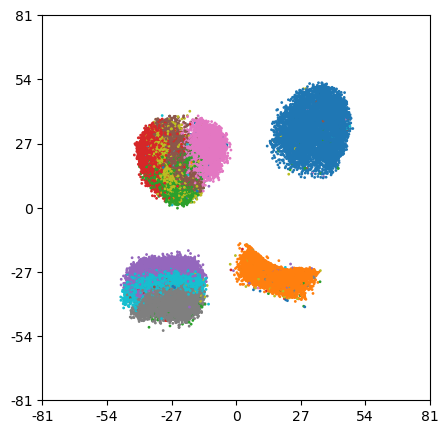

In [65]:
plt.figure(figsize = [5,5])
plt.xlim(-65,97)
plt.ylim(-81,81)
plt.xticks(np.linspace(-65,97,7), np.linspace(-81,81,7).astype(int))
plt.yticks(np.linspace(-81,81,7), np.linspace(-81,81,7).astype(int))
plt.scatter(ce_4_[:,0], ce_4_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.savefig('../figures/mnist/cluster4.png', format='png', dpi=300, bbox_inches='tight')

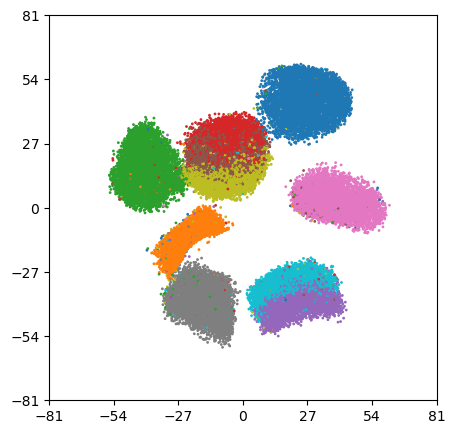

In [66]:
plt.figure(figsize = [5,5])
plt.scatter(ce_7_[:,0], ce_7_[:,1], c = labels, cmap = 'tab10', s = 1)

plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/cluster7.png', format='png', dpi=300, bbox_inches='tight')

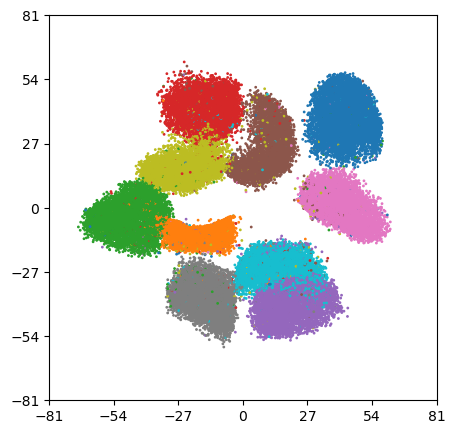

In [68]:
plt.figure(figsize = [5,5])
plt.scatter(ce_10[:,0], ce_10[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/cluster10.png', format='png', dpi=300, bbox_inches='tight')

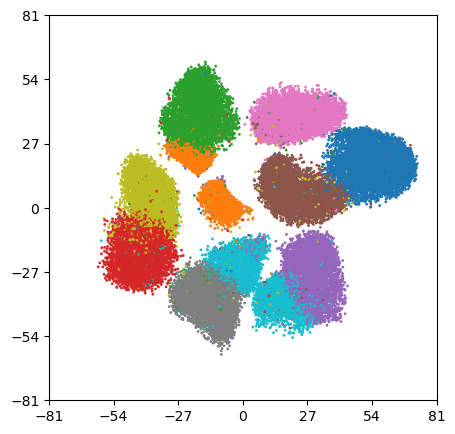

In [94]:
plt.figure(figsize = [5,5])
plt.scatter(ce_12_[:,0], ce_12_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/cluster12.png', format='png', dpi=300, bbox_inches='tight')

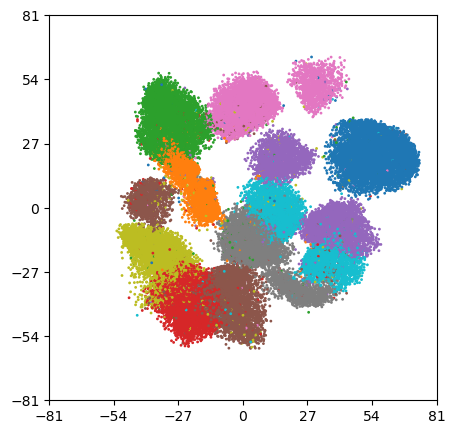

In [96]:
plt.figure(figsize = [5,5])
plt.scatter(ce_16_[:,0], -ce_16_[:,1], c = labels, cmap = 'tab10', s = 1)

plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/cluster16.png', format='png', dpi=300, bbox_inches='tight')

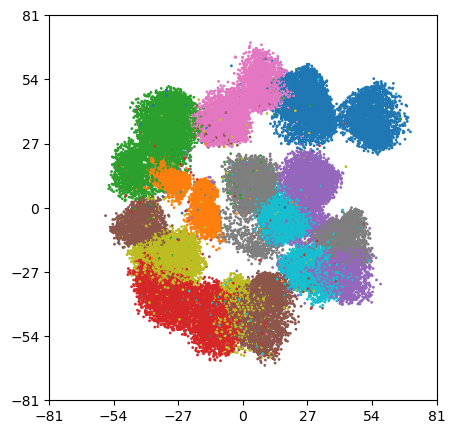

In [98]:
plt.figure(figsize = [5,5])
plt.scatter(ce_24_[:,0], -ce_24_[:,1], c = labels, cmap = 'tab10', s = 1)

plt.xlim(-81,81)
plt.ylim(-81,81)
plt.xticks(np.linspace(-81,81,7))
plt.yticks(np.linspace(-81,81,7))
plt.savefig('../figures/mnist/cluster24.png', format='png', dpi=300, bbox_inches='tight')

In [99]:
with open('../results/mnist/clustering_embs.pkl', 'wb') as file:  
    pickle.dump([ce_4, ce_7, ce_12, ce_16, ce_24], file)

In [100]:
geodesic_distances = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/MNIST_geodesic_5.csv")
geodesic_distances = squareform(geodesic_distances.to_numpy().flatten())
geodesic_distances.shape

(5000, 5000)

In [101]:
all_embs = [ce_4, ce_7, ce_10, ce_12, ce_16, ce_24]

In [102]:
orig_distances = geodesic_distances

for emb in all_embs:
    emb_distances =  squareform(pdist(emb[0:5000]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[0:5000])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[0:5000])
    class_score = class_preservation(orig_distances, emb_distances, labels[0:5000])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[0:5000])
    recall_score = knn_recall(mnist[0:5000], emb[0:5000], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.73$ & $0.63$ & $0.52$ & $0.25$ & $0.32$ & $0.44$ & $0.52$ & $0.55$ & $0.29$ & $0.45$ & $0.46$

$0.80$ & $0.55$ & $0.44$ & $0.33$ & $0.43$ & $0.58$ & $0.47$ & $0.52$ & $0.24$ & $0.36$ & $0.65$

$0.80$ & $0.53$ & $0.44$ & $0.37$ & $0.42$ & $0.61$ & $0.51$ & $0.58$ & $0.23$ & $0.34$ & $0.73$

$0.80$ & $0.51$ & $0.43$ & $0.37$ & $0.38$ & $0.56$ & $0.53$ & $0.60$ & $0.24$ & $0.35$ & $0.54$

$0.78$ & $0.48$ & $0.42$ & $0.36$ & $0.39$ & $0.54$ & $0.55$ & $0.60$ & $0.26$ & $0.37$ & $0.49$

$0.72$ & $0.46$ & $0.40$ & $0.37$ & $0.39$ & $0.55$ & $0.55$ & $0.59$ & $0.27$ & $0.36$ & $0.58$

